# EI-Beginner 任务一

1. 坐标变换与齐次变换矩阵
2. 二连杆机械臂的正运动学与逆运动学
3. 在 `PyBullet` 中加载机械臂，理解关节和末端执行器
4. 用逆运动学让末端执行器移动到目标附近
5. 理解为什么任务一是“传统机器人学”而不是“强化学习”


## 任务要求拆解

这个 notebook 先解决最关键的入门部分：

- 会写和看懂 2D/3D 坐标变换
- 会做最基础的正运动学（Forward Kinematics）
- 会做最基础的逆运动学（Inverse Kinematics）
- 能在 PyBullet 里把 IK 用到机械臂上

动力学和控制可以在你跑通这里之后继续扩展。

In [ ]:
# 如果缺依赖，可以取消注释后运行
# %pip install -U numpy matplotlib pybullet

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
np.set_printoptions(precision=4, suppress=True)

## Part A: 坐标变换与齐次矩阵

机器人学里最基础的问题之一是：

- 一个点在局部坐标系里的坐标已知
- 机械臂连杆、末端执行器、物体都在不同坐标系里
- 如何把它们变换到同一个坐标系里讨论

齐次变换矩阵就是为这个服务的。

In [2]:
def rot2d(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s],
        [s,  c],
    ])


def transform2d(theta, tx, ty):
    T = np.eye(3)
    T[:2, :2] = rot2d(theta)
    T[:2, 2] = [tx, ty]
    return T


theta = np.deg2rad(30)
T = transform2d(theta, tx=2.0, ty=1.0)
point_local = np.array([1.0, 0.5, 1.0])
point_world = T @ point_local

print('2D homogeneous transform T =')
print(T)
print('point_local =', point_local)
print('point_world =', point_world)

2D homogeneous transform T =
[[ 0.866 -0.5    2.   ]
 [ 0.5    0.866  1.   ]
 [ 0.     0.     1.   ]]
point_local = [1.  0.5 1. ]
point_world = [2.616 1.933 1.   ]


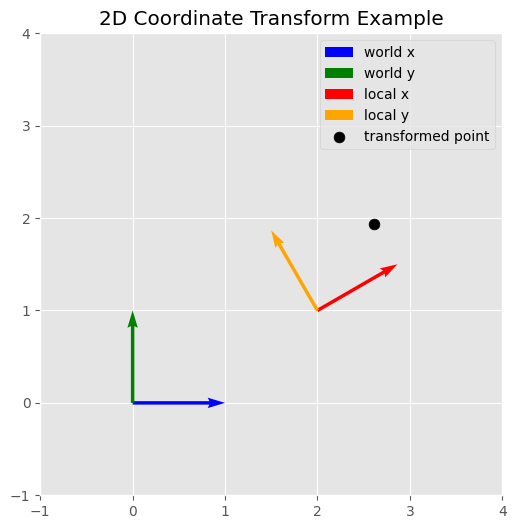

In [3]:
origin = np.array([0, 0])
x_axis = T[:2, :2] @ np.array([1, 0])
y_axis = T[:2, :2] @ np.array([0, 1])
translated_origin = T[:2, 2]

plt.figure(figsize=(6, 6))
plt.quiver(*origin, 1, 0, angles='xy', scale_units='xy', scale=1, color='blue', label='world x')
plt.quiver(*origin, 0, 1, angles='xy', scale_units='xy', scale=1, color='green', label='world y')
plt.quiver(*translated_origin, *x_axis, angles='xy', scale_units='xy', scale=1, color='red', label='local x')
plt.quiver(*translated_origin, *y_axis, angles='xy', scale_units='xy', scale=1, color='orange', label='local y')
plt.scatter(point_world[0], point_world[1], color='black', s=60, label='transformed point')
plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('2D Coordinate Transform Example')
plt.show()

### 这里你应该理解什么

- 旋转矩阵负责方向变化
- 平移向量负责位置变化
- 齐次矩阵把旋转和平移统一在一个矩阵里
- 多段连杆的位姿变换，本质上就是一连串矩阵乘法


## Part B: 二连杆机械臂的正运动学

先从二维平面二连杆开始，这是最适合入门的模型。

设：
- 第一段长度 `l1`
- 第二段长度 `l2`
- 关节角分别为 `theta1, theta2`

末端位置公式是：

- `x = l1*cos(theta1) + l2*cos(theta1 + theta2)`
- `y = l1*sin(theta1) + l2*sin(theta1 + theta2)`


In [4]:
def fk_2link(theta1, theta2, l1=1.0, l2=0.8):
    joint1 = np.array([l1 * np.cos(theta1), l1 * np.sin(theta1)])
    end_effector = joint1 + np.array([
        l2 * np.cos(theta1 + theta2),
        l2 * np.sin(theta1 + theta2),
    ])
    return joint1, end_effector


theta1 = np.deg2rad(45)
theta2 = np.deg2rad(-30)
joint1, ee = fk_2link(theta1, theta2)

print('joint1 =', joint1)
print('end_effector =', ee)

joint1 = [0.7071 0.7071]
end_effector = [1.4798 0.9142]


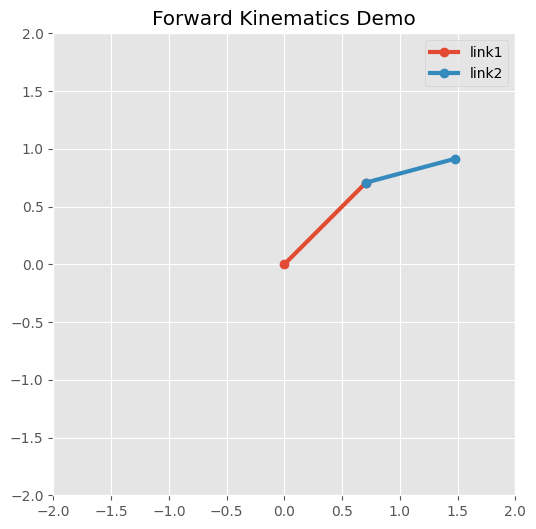

In [5]:
def plot_2link(theta1, theta2, l1=1.0, l2=0.8, target=None, title='2-Link Arm'):
    base = np.array([0.0, 0.0])
    joint1, ee = fk_2link(theta1, theta2, l1, l2)

    plt.figure(figsize=(6, 6))
    plt.plot([base[0], joint1[0]], [base[1], joint1[1]], '-o', linewidth=3, label='link1')
    plt.plot([joint1[0], ee[0]], [joint1[1], ee[1]], '-o', linewidth=3, label='link2')
    if target is not None:
        plt.scatter(target[0], target[1], c='red', s=80, label='target')
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.legend()
    plt.show()


plot_2link(theta1, theta2, title='Forward Kinematics Demo')

## Part C: 二连杆逆运动学

逆运动学问的是反问题：

- 目标末端位置给定
- 求应该设置什么关节角

二连杆可以写出解析解。

In [6]:
def ik_2link(x, y, l1=1.0, l2=0.8, elbow_up=True):
    r2 = x**2 + y**2
    cos_theta2 = (r2 - l1**2 - l2**2) / (2 * l1 * l2)
    cos_theta2 = np.clip(cos_theta2, -1.0, 1.0)
    sin_theta2 = np.sqrt(1 - cos_theta2**2)
    if not elbow_up:
        sin_theta2 = -sin_theta2

    theta2 = np.arctan2(sin_theta2, cos_theta2)
    k1 = l1 + l2 * cos_theta2
    k2 = l2 * sin_theta2
    theta1 = np.arctan2(y, x) - np.arctan2(k2, k1)
    return theta1, theta2


target = np.array([1.2, 0.8])
theta1_ik, theta2_ik = ik_2link(target[0], target[1], elbow_up=True)
joint1_ik, ee_ik = fk_2link(theta1_ik, theta2_ik)

print('theta1 (deg) =', np.rad2deg(theta1_ik))
print('theta2 (deg) =', np.rad2deg(theta2_ik))
print('reconstructed ee =', ee_ik)
print('target =', target)
print('error =', np.linalg.norm(ee_ik - target))

theta1 (deg) = 1.4604717387654091
theta2 (deg) = 74.03798583715277
reconstructed ee = [1.2 0.8]
target = [1.2 0.8]
error = 2.482534153247273e-16


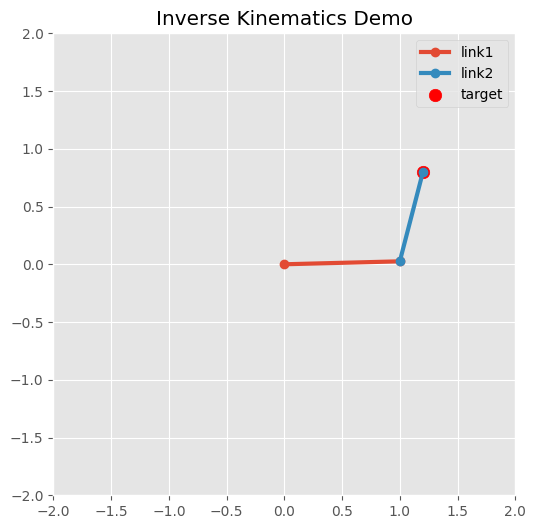

In [7]:
plot_2link(theta1_ik, theta2_ik, target=target, title='Inverse Kinematics Demo')

### 正运动学和逆运动学的区别

- 正运动学：已知关节角，求末端位置
- 逆运动学：已知末端目标，求关节角

机械臂抓取时通常是：
- 先通过视觉或规则拿到目标位姿
- 再通过逆运动学求解关节控制目标
- 最后由控制器去执行这些目标


## Part D: 在 PyBullet 中加载 Panda 机械臂

现在把前面的运动学思想迁移到仿真环境中。

这里先做几件基础但很重要的事：

- 启动 PyBullet
- 加载地面和 Panda 机械臂
- 查看关节索引和名称
- 找出末端执行器 link


In [8]:
import pybullet as p
import pybullet_data


def connect_pybullet(gui=False):
    mode = p.GUI if gui else p.DIRECT
    client = p.connect(mode)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    p.resetDebugVisualizerCamera(
        cameraDistance=1.5,
        cameraYaw=45,
        cameraPitch=-35,
        cameraTargetPosition=[0.5, 0, 0.2],
    )
    return client


client_id = connect_pybullet(gui=False)
plane_id = p.loadURDF('plane.urdf')
robot_id = p.loadURDF('franka_panda/panda.urdf', useFixedBase=True)

num_joints = p.getNumJoints(robot_id)
print('num_joints =', num_joints)

pybullet build time: Jan 29 2025 23:16:28


num_joints = 12


In [9]:
joint_info = []
for i in range(num_joints):
    info = p.getJointInfo(robot_id, i)
    joint_info.append({
        'joint_index': info[0],
        'joint_name': info[1].decode('utf-8'),
        'joint_type': info[2],
        'lower_limit': info[8],
        'upper_limit': info[9],
        'link_name': info[12].decode('utf-8'),
    })

joint_info[:12]

[{'joint_index': 0,
  'joint_name': 'panda_joint1',
  'joint_type': 0,
  'lower_limit': -2.9671,
  'upper_limit': 2.9671,
  'link_name': 'panda_link1'},
 {'joint_index': 1,
  'joint_name': 'panda_joint2',
  'joint_type': 0,
  'lower_limit': -1.8326,
  'upper_limit': 1.8326,
  'link_name': 'panda_link2'},
 {'joint_index': 2,
  'joint_name': 'panda_joint3',
  'joint_type': 0,
  'lower_limit': -2.9671,
  'upper_limit': 2.9671,
  'link_name': 'panda_link3'},
 {'joint_index': 3,
  'joint_name': 'panda_joint4',
  'joint_type': 0,
  'lower_limit': -3.1416,
  'upper_limit': 0.0,
  'link_name': 'panda_link4'},
 {'joint_index': 4,
  'joint_name': 'panda_joint5',
  'joint_type': 0,
  'lower_limit': -2.9671,
  'upper_limit': 2.9671,
  'link_name': 'panda_link5'},
 {'joint_index': 5,
  'joint_name': 'panda_joint6',
  'joint_type': 0,
  'lower_limit': -0.0873,
  'upper_limit': 3.8223,
  'link_name': 'panda_link6'},
 {'joint_index': 6,
  'joint_name': 'panda_joint7',
  'joint_type': 0,
  'lower_limit

In [10]:
# Panda 常用的 7 个 arm joints
arm_joint_indices = [0, 1, 2, 3, 4, 5, 6]
gripper_joint_indices = [9, 10]
ee_link_index = 11

print('arm_joint_indices =', arm_joint_indices)
print('gripper_joint_indices =', gripper_joint_indices)
print('ee_link_index =', ee_link_index)

arm_joint_indices = [0, 1, 2, 3, 4, 5, 6]
gripper_joint_indices = [9, 10]
ee_link_index = 11


## Part E: 用逆运动学控制 Panda 末端移动

这里不做复杂控制器，直接使用 PyBullet 提供的逆运动学求解器 `calculateInverseKinematics`。

这一步的学习目标是：

- 给定一个目标末端位置
- 求出一组关节角
- 用关节位置控制把机械臂带到目标附近


In [40]:
def reset_panda(robot_id):
    initial_positions = [0.0, -0.3, 0.0, -2.2, 0.0, 2.0, 0.8]
    for joint_index, joint_pos in zip(arm_joint_indices, initial_positions):
        p.resetJointState(robot_id, joint_index, joint_pos)
    p.resetJointState(robot_id, 9, 0.04)
    p.resetJointState(robot_id, 10, 0.04)


def get_ee_position(robot_id, ee_link_index=11):
    state = p.getLinkState(robot_id, ee_link_index)
    return np.array(state[4])


def get_ee_pose(robot_id, ee_link_index=11):
    state = p.getLinkState(robot_id, ee_link_index)
    return np.array(state[4]), np.array(state[5])


def step_simulation(steps=1, frames=None, frame_interval=4):
    for step_idx in range(steps):
        p.stepSimulation()
        if frames is not None and step_idx % frame_interval == 0:
            frames.append(render_pybullet_rgb())


def set_gripper_opening(robot_id, opening=0.04, steps=120, force=120, frames=None):
    for _ in range(steps):
        for grip_joint in gripper_joint_indices:
            p.setJointMotorControl2(
                robot_id,
                grip_joint,
                p.POSITION_CONTROL,
                targetPosition=opening,
                force=force,
            )
        step_simulation(1, frames=frames, frame_interval=1)


def move_ee_to_target(robot_id, target_position, target_orientation=None, steps=240, frames=None):
    if target_orientation is None:
        joint_targets = p.calculateInverseKinematics(robot_id, ee_link_index, target_position)
    else:
        joint_targets = p.calculateInverseKinematics(
            robot_id,
            ee_link_index,
            target_position,
            target_orientation,
            maxNumIterations=200,
            residualThreshold=1e-4,
        )

    for _ in range(steps):
        for joint_index, joint_target in zip(arm_joint_indices, joint_targets[:7]):
            p.setJointMotorControl2(
                robot_id,
                joint_index,
                controlMode=p.POSITION_CONTROL,
                targetPosition=joint_target,
                force=240,
            )
        step_simulation(1, frames=frames, frame_interval=1)
    return get_ee_position(robot_id)


reset_panda(robot_id)
target_position = np.array([0.45, 0.15, 0.25])
final_ee = move_ee_to_target(robot_id, target_position)

print('target_position =', target_position)
print('final_ee =', final_ee)
print('position_error =', np.linalg.norm(final_ee - target_position))

target_position = [0.45 0.15 0.25]
final_ee = [0.4467 0.1489 0.2524]
position_error = 0.004189357519773501


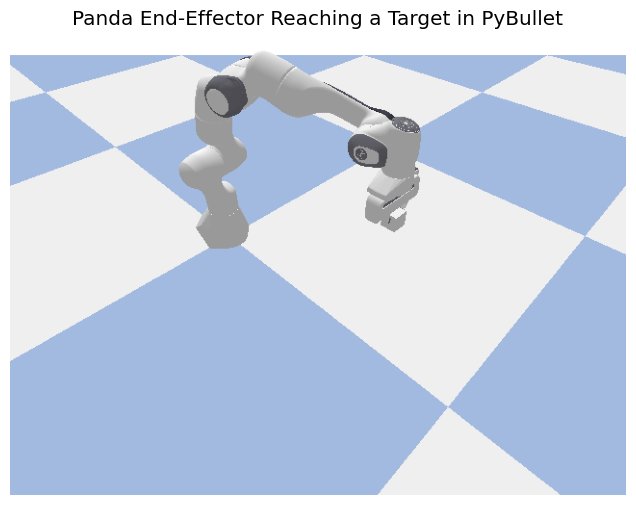

In [49]:
def render_pybullet_rgb(width=640, height=480):
    view_matrix = p.computeViewMatrixFromYawPitchRoll(
        cameraTargetPosition=[0.5, 0.0, 0.2],
        distance=1.2,
        yaw=45,
        pitch=-45,
        roll=0,
        upAxisIndex=2,
    )
    proj_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width / height,
        nearVal=0.1,
        farVal=3.1,
    )
    _, _, rgba, _, _ = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=proj_matrix,
        renderer=p.ER_BULLET_HARDWARE_OPENGL,
    )
    rgba = np.reshape(rgba, (height, width, 4))
    return rgba[:, :, :3]


img = render_pybullet_rgb()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Panda End-Effector Reaching a Target in PyBullet')
plt.show()

## Part F: 从接近目标到“抓取”

严格意义上的抓取通常还需要：

- 物体检测或已知物体位姿
- 规划预抓取位姿
- 末端移动到抓取姿态
- 闭合夹爪
- 抬升物体

下面给一个简化版思路，只强调流程。

In [43]:
def clear_grasp_scene():
    global cube_id, grasp_constraint_id
    if 'grasp_constraint_id' in globals() and grasp_constraint_id is not None:
        try:
            p.removeConstraint(grasp_constraint_id)
        except Exception:
            pass
        grasp_constraint_id = None
    if 'cube_id' in globals() and cube_id is not None:
        try:
            p.removeBody(cube_id)
        except Exception:
            pass
        cube_id = None


def spawn_cube(base_position=(0.55, 0.0, 0.025)):
    global cube_id
    clear_grasp_scene()
    cube_id = p.loadURDF('cube_small.urdf', basePosition=base_position)
    return cube_id


def attach_cube_to_ee(robot_id, cube_id):
    global grasp_constraint_id
    ee_pos, ee_orn = get_ee_pose(robot_id, ee_link_index)
    cube_pos, cube_orn = p.getBasePositionAndOrientation(cube_id)
    inv_pos, inv_orn = p.invertTransform(ee_pos, ee_orn)
    parent_frame_pos, parent_frame_orn = p.multiplyTransforms(inv_pos, inv_orn, cube_pos, cube_orn)
    grasp_constraint_id = p.createConstraint(
        robot_id,
        ee_link_index,
        cube_id,
        -1,
        p.JOINT_FIXED,
        [0, 0, 0],
        parent_frame_pos,
        [0, 0, 0],
        parentFrameOrientation=parent_frame_orn,
        childFrameOrientation=[0, 0, 0, 1],
    )
    return grasp_constraint_id


cube_id = spawn_cube()
print('cube_id =', cube_id)

cube_id = 2


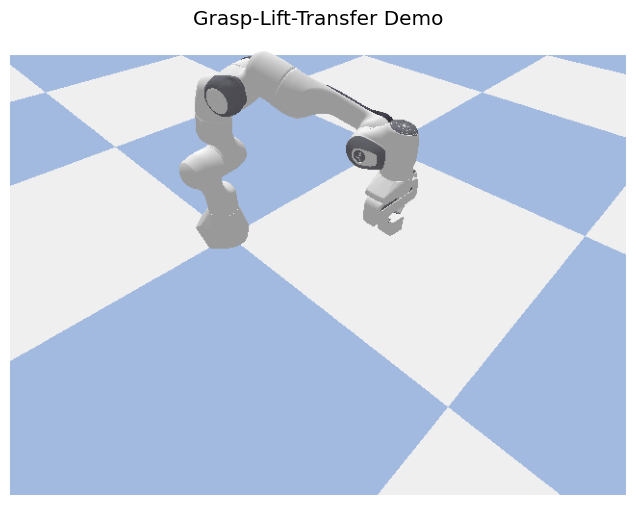

cube_final_pos = [0.5993 0.201  0.3001]
video saved to project1_panda_grasp_demo.mp4


In [52]:
import mediapy
from IPython.display import Video, display

reset_panda(robot_id)
cube_id = spawn_cube(base_position=(0.55, 0.0, 0.025))
frames = [render_pybullet_rgb()]

# 让夹爪朝下，便于做顶抓示例。
grasp_orientation = p.getQuaternionFromEuler([np.pi, 0.0, 0.0])
pre_grasp = np.array([0.55, 0.0, 0.22])
grasp_pose = np.array([0.55, 0.0, 0.03])
lift_pose = np.array([0.55, 0.0, 0.30])
place_pose = np.array([0.60, 0.20, 0.32])

set_gripper_opening(robot_id, opening=0.04, steps=20, force=120, frames=frames)
move_ee_to_target(robot_id, pre_grasp, target_orientation=grasp_orientation, steps=30, frames=frames)
move_ee_to_target(robot_id, grasp_pose, target_orientation=grasp_orientation, steps=30, frames=frames)
set_gripper_opening(robot_id, opening=0.0, steps=20, force=300, frames=frames)

# 用固定约束模拟稳定抓取，便于学习完整的抓取流程。
# attach_cube_to_ee(robot_id, cube_id)
move_ee_to_target(robot_id, lift_pose, target_orientation=grasp_orientation, steps=20, frames=frames)
move_ee_to_target(robot_id, place_pose, target_orientation=grasp_orientation, steps=30, frames=frames)

cube_final_pos, _ = p.getBasePositionAndOrientation(cube_id)
img = render_pybullet_rgb()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Grasp-Lift-Transfer Demo')
plt.show()

video_path = 'project1_panda_grasp_demo.mp4'
mediapy.write_video(video_path, frames, fps=20)
display(Video(video_path, embed=True))

print('cube_final_pos =', np.array(cube_final_pos))
print('video saved to', video_path)

In [33]:
# 如果你想手动清理场景，可以运行：
# clear_grasp_scene()